## 7. Social Vulnerability Analysis

This section uses ABS Census data to measure social vulnerability at the SA2 level. The indicators include median household income, elderly population percentage, children population percentage and population density. This part is later used as one input for the final priority intervention index.
### 7.1 Load packages and set folders

In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import os

In [4]:
# set folder paths
raw_path = "../data/raw"
processed_path = "../data/processed"
figure_path = "../output/figures"
table_path = "../output/tables"

# make folders for processed data and outputs
os.makedirs(processed_path, exist_ok=True)
os.makedirs(figure_path, exist_ok=True)
os.makedirs(table_path, exist_ok=True)

['urban_heat', 'boundary', '.gitkeep', 'open_space', 'census']


### 7.2 Load and prepare SA2 boundary

In [7]:
# load final study area boundary
sa2_melb = gpd.read_file(raw_path + "/boundary/study_area.gpkg")
# check first few rows
sa2_melb.head()

,id,SA2_CODE_2021,SA2_NAME_2021,CHANGE_FLAG_2021,CHANGE_LABEL_2021,SA3_CODE_2021,SA3_NAME_2021,SA4_CODE_2021,SA4_NAME_2021,GCCSA_CODE_2021,GCCSA_NAME_2021,STATE_CODE_2021,STATE_NAME_2021,AUS_CODE_2021,AUS_NAME_2021,AREA_ALBERS_SQKM,ASGS_LOCI_URI_2021,geometry
0,1081,213051362,Hoppers Crossing - South,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,7.0114,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((144.66540 -37.87010, 144.66529..."
1,1083,213051368,Werribee - South,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,114.0332,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((144.73479 -37.94361, 144.73479..."
2,1086,213051467,Werribee - East,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,7.7569,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((144.64116 -37.88193, 144.64109..."
3,1087,213051468,Werribee - West,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,127.6631,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((144.59729 -37.94211, 144.59733..."
4,1088,213051579,Manor Lakes - Quandong,1,New,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,72.0339,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((144.51648 -37.87412, 144.54997..."


In [8]:
# check column names
sa2_melb.columns

Index(['id', 'SA2_CODE_2021', 'SA2_NAME_2021', 'CHANGE_FLAG_2021',
       'CHANGE_LABEL_2021', 'SA3_CODE_2021', 'SA3_NAME_2021', 'SA4_CODE_2021',
       'SA4_NAME_2021', 'GCCSA_CODE_2021', 'GCCSA_NAME_2021',
       'STATE_CODE_2021', 'STATE_NAME_2021', 'AUS_CODE_2021', 'AUS_NAME_2021',
       'AREA_ALBERS_SQKM', 'ASGS_LOCI_URI_2021', 'geometry'],
      dtype='object')

In [9]:
# rename columns to simple names
sa2_melb = sa2_melb.rename(columns={
    "SA2_CODE_2021": "sa2_code",
    "SA2_NAME_2021": "sa2_name"})

In [26]:
# project to EPSG:7855 for area calculation
sa2_melb = sa2_melb.to_crs(epsg=7855)

# calculate SA2 area in km2
sa2_melb["area_km2"] = sa2_melb.geometry.area / 1000000

sa2_melb["sa2_code"] = sa2_melb["sa2_code"].astype(str)
sa2_melb = sa2_melb[["sa2_code", "sa2_name", "area_km2", "geometry"]]

sa2_melb.head()

,sa2_code,sa2_name,area_km2,geometry
0,213051362,Hoppers Crossing - South,7.012411,"MULTIPOLYGON (((294653.085 5806028.552, 294645..."
1,213051368,Werribee - South,114.061560,"MULTIPOLYGON (((300955.332 5798020.917, 300955..."
2,213051467,Werribee - East,7.758551,"MULTIPOLYGON (((292554.398 5804662.406, 292548..."
3,213051468,Werribee - West,59.916045,"MULTIPOLYGON (((288867.598 5797885.557, 288870..."
4,213051579,Manor Lakes - Quandong,14.935574,"MULTIPOLYGON (((281564.588 5805244.323, 284521..."


In [27]:
# save cleaned SA2 boundary
sa2_melb.to_file(
    processed_path + "/sa2_melbourne_clean.gpkg",
    driver="GPKG")

The study area boundary was provided as a prepared SA2 layer. It was used as the spatial base for joining Census indicators.

### 7.3 Load Census tables
The Census G01 table was used for age and population variables. The G02 table was used for median weekly household income.

In [28]:
# read G01 and G02 census tables
g01 = pd.read_csv(raw_path + "/census/2021Census_G01_VIC_SA2.csv")
g02 = pd.read_csv(raw_path + "/census/2021Census_G02_VIC_SA2.csv")

g01.head()

,SA2_CODE_2021,Tot_P_M,Tot_P_F,Tot_P_P,Age_0_4_yr_M,Age_0_4_yr_F,Age_0_4_yr_P,Age_5_14_yr_M,Age_5_14_yr_F,Age_5_14_yr_P,...,High_yr_schl_comp_Yr_8_belw_P,High_yr_schl_comp_D_n_g_sch_M,High_yr_schl_comp_D_n_g_sch_F,High_yr_schl_comp_D_n_g_sch_P,Count_psns_occ_priv_dwgs_M,Count_psns_occ_priv_dwgs_F,Count_psns_occ_priv_dwgs_P,Count_Persons_other_dwgs_M,Count_Persons_other_dwgs_F,Count_Persons_other_dwgs_P
0,201011001,8188,8648,16835,623,585,1213,1453,1364,2815,...,430,23,22,45,7786,8263,16055,268,313,585
1,201011002,5711,6420,12131,267,224,490,658,630,1290,...,355,10,13,22,5152,5811,10969,755,766,1521
2,201011005,3594,3664,7261,190,172,357,561,587,1148,...,169,10,8,14,3308,3417,6722,217,215,435
3,201011006,5111,5553,10661,382,426,804,784,683,1464,...,408,22,13,39,4837,5211,10052,227,270,501
4,201011007,2172,2055,4230,125,99,223,338,326,668,...,126,4,3,8,2099,2013,4107,37,37,71


### 7.4 Prepare age and population indicators

In [31]:
g01_clean = g01.copy()
g01_clean["sa2_code"] = g01_clean["SA2_CODE_2021"].astype(str)

# calculate children population(children are defined as people aged 0 to 14)
g01_clean["children_pop"] = (
    g01_clean["Age_0_4_yr_P"] +
    g01_clean["Age_5_14_yr_P"])

# calculate elderly population(elderly people are defined as people aged 65 and over)
g01_clean["elderly_pop"] = (
    g01_clean["Age_65_74_yr_P"] +
    g01_clean["Age_75_84_yr_P"] +
    g01_clean["Age_85ov_P"])

# total population
g01_clean["total_population"] = g01_clean["Tot_P_P"]

# calculate percentage
g01_clean["children_pct"] = (g01_clean["children_pop"] / g01_clean["total_population"] * 100)

g01_clean["elderly_pct"] = (g01_clean["elderly_pop"] / g01_clean["total_population"] * 100)

# keep useful columns
g01_clean = g01_clean[
    [
        "sa2_code",
        "children_pop",
        "elderly_pop",
        "total_population",
        "children_pct",
        "elderly_pct"]]

g01_clean.head()

,sa2_code,children_pop,elderly_pop,total_population,children_pct,elderly_pct
0,201011001,4028,2178,16835,23.926344,12.937333
1,201011002,1780,2826,12131,14.673151,23.295689
2,201011005,1505,1334,7261,20.727173,18.372125
3,201011006,2268,1578,10661,21.273802,14.801613
4,201011007,891,608,4230,21.063830,14.373522


Median weekly household income was selected as the income indicator. A lower income is later treated as higher vulnerability.

In [37]:
g02_clean = g02.copy()
g02_clean["sa2_code"] = g02_clean["SA2_CODE_2021"].astype(str)

# use median household income
g02_clean["median_income"] = g02_clean["Median_tot_hhd_inc_weekly"]

# keep useful columns
g02_clean = g02_clean[[ "sa2_code","median_income"]]

g02_clean.head()

,sa2_code,median_income
0,201011001,1952
1,201011002,1573
2,201011005,1927
3,201011006,1627
4,201011007,2065


In [38]:
# merge age/population table with income table
census_clean = g01_clean.merge(
    g02_clean,
    on="sa2_code",
    how="left")

census_clean.head()

,sa2_code,children_pop,elderly_pop,total_population,children_pct,elderly_pct,median_income
0,201011001,4028,2178,16835,23.926344,12.937333,1952
1,201011002,1780,2826,12131,14.673151,23.295689,1573
2,201011005,1505,1334,7261,20.727173,18.372125,1927
3,201011006,2268,1578,10661,21.273802,14.801613,1627
4,201011007,891,608,4230,21.063830,14.373522,2065


In [39]:
# remove rows with missing values in selected indicators
census_clean = census_clean.dropna(
    subset=["children_pct", "elderly_pct", "total_population", "median_income"])

### 7.5 Join Census indicators to SA2 boundary

In [41]:
# merge census data with SA2 boundary
sa2_census = sa2_melb.merge(
    census_clean,
    on="sa2_code",
    how="left")

# calculate population density
sa2_census["population_density"] = (sa2_census["total_population"] / sa2_census["area_km2"])

sa2_census[[
        "sa2_code",
        "sa2_name",
        "median_income",
        "children_pct",
        "elderly_pct",
        "population_density"]].head()

,sa2_code,sa2_name,median_income,children_pct,elderly_pct,population_density
0,213051362,Hoppers Crossing - South,1470.0,19.470488,15.619007,2676.967910
1,213051368,Werribee - South,1802.0,18.887567,15.425342,147.376557
2,213051467,Werribee - East,1374.0,19.495003,15.228827,2450.199801
3,213051468,Werribee - West,1995.0,23.123405,8.030079,372.871741
4,213051579,Manor Lakes - Quandong,2309.0,30.519970,3.570083,710.786197


In [42]:
# check missing values after joining
sa2_census[
    ["median_income", "children_pct", "elderly_pct", "population_density"]
].isna().sum()

median_income         2
children_pct          2
elderly_pct           2
population_density    2
dtype: int64

### 7.6 Calculate social vulnerability score

All indicators were standardised to a 0–1 scale before calculating the score. Income was reversed because lower income means higher vulnerability. Elderly percentage, children percentage and population density were treated as positive indicators, where higher values mean higher vulnerability or exposure.

In [43]:
# function for min-max standardisation
def standardise(column):
    return (column - column.min()) / (column.max() - column.min())

# reverse standardisation
def reverse_standardise(column):
    return (column.max() - column) / (column.max() - column.min())

In [44]:
# calculate vulnerability scores
sa2_census["income_score"] = reverse_standardise(sa2_census["median_income"])
sa2_census["elderly_score"] = standardise(sa2_census["elderly_pct"])
sa2_census["children_score"] = standardise(sa2_census["children_pct"])
sa2_census["density_score"] = standardise(sa2_census["population_density"])

# calculate final social vulnerability score
sa2_census["social_vulnerability_score"] = (
    sa2_census["income_score"] +
    sa2_census["elderly_score"] +
    sa2_census["children_score"] +
    sa2_census["density_score"]) / 4

**Table X. Top 10 SA2s with the highest social vulnerability score.**

In [46]:
# make top 10 social vulnerability table
top_social = sa2_census.sort_values(
    by="social_vulnerability_score",
    ascending=False
).head(10)

top_social_table = top_social[
    [ "sa2_name",
        "median_income",
        "elderly_pct",
        "children_pct",
        "population_density",
        "social_vulnerability_score"]].copy()

top_social_table

,sa2_name,median_income,elderly_pct,children_pct,population_density,social_vulnerability_score
36,Riddells Creek,2156.0,16.805026,19.250617,9.554337e+08,0.573641
34,Romsey,2004.0,16.720855,19.609847,5.722693e+08,0.488679
162,Rosebud - McCrae,1155.0,33.372559,14.029812,9.642079e+02,0.475846
185,Mornington - West,1389.0,38.701446,10.802382,1.652279e+03,0.465037
11,Point Nepean,1430.0,32.239665,13.871082,2.948333e+02,0.443697
20,Melton,1061.0,20.213036,18.792797,7.994316e+02,0.436030
163,Dromana,1398.0,30.734700,13.444561,2.966541e+02,0.433397
184,Mornington - East,1502.0,26.003295,17.930807,1.033186e+03,0.428880
59,Campbellfield - Coolaroo,1104.0,15.638039,21.679018,8.828945e+02,0.425286
19,Melton South - Weir Views,1363.0,10.991716,26.695882,1.511003e+03,0.412157


In [49]:
# save top 10 table
top_social_table.to_csv(
    table_path + "/top_10_social_vulnerability_SA2.csv",
    index=False)

In [50]:
# save census indicators for later merge
sa2_census.drop(columns="geometry").to_csv(
    processed_path + "/census_indicators_by_SA2.csv",
    index=False)

### 7.7 Map social vulnerability

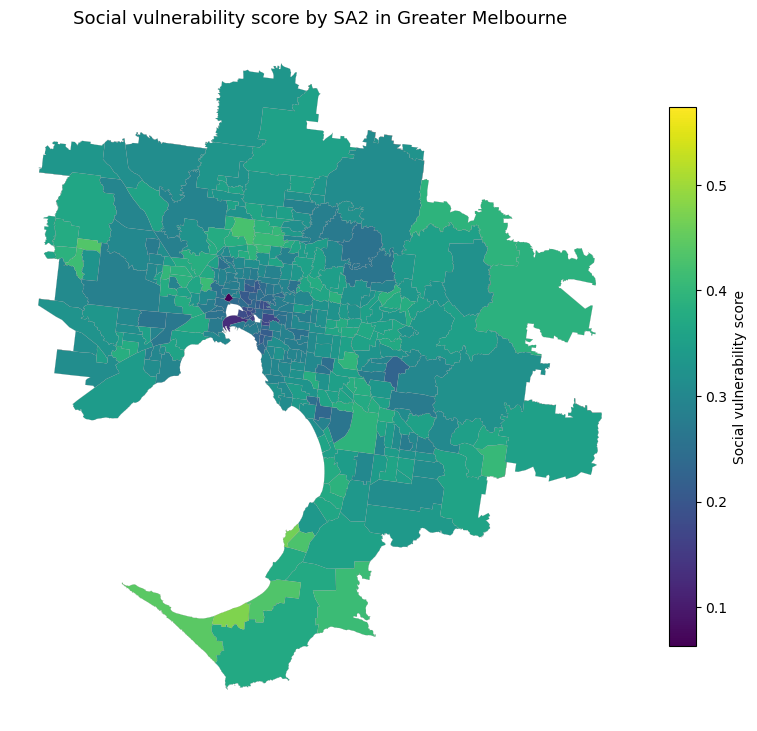

In [52]:
fig, ax = plt.subplots(figsize=(10, 10))

sa2_census.plot(
    column="social_vulnerability_score",
    legend=True,
    legend_kwds={
        "label": "Social vulnerability score",
        "shrink": 0.7},
    edgecolor="grey",
    linewidth=0.1,
    ax=ax)

ax.set_title("Social vulnerability score by SA2 in Greater Melbourne", fontsize=13)
ax.axis("off")

fig.savefig(
    figure_path + "/social_vulnerability_map.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

**Figure X. Social vulnerability score by SA2 in Greater Melbourne.**  
Higher values show SA2s with higher social vulnerability based on weekly median household income, elderly population percentage, children population percentage and population density.